## 편의점 분석

### STEP0. 분석 환경 설정

In [1]:

from pathlib import Path
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 데이터 폴더
DATA_DIR = Path("./data")

# 결과 저장 폴더
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(exist_ok=True)


# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


### STEP 1. 사용할 데이터 전체 불러오기

In [2]:
# STEP 1-1. CSV 불러오기 함수
def read_csv_auto(path, household=False):

    # 세대원수 파일은 CSV 구조가 특이해서 별도 처리
    if household:

        df = pd.read_csv(
            path,
            encoding="utf-8-sig",
            engine="python",
            quoting=csv.QUOTE_NONE
        )

        # 따옴표 제거
        df.columns = [
            str(col).strip('"')
            for col in df.columns
        ]

        for col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip('"')
            )

        return df

    # 일반 CSV
    for encoding in ["utf-8-sig", "cp949"]:

        try:
            return pd.read_csv(
                path,
                encoding=encoding
            )

        except UnicodeDecodeError:
            continue

    return pd.read_csv(
        path,
        encoding="cp949",
        engine="python"
    )

In [3]:
# STEP 1-2. 전체 데이터 불러오기

# ① 3개년 편의점
store_2023 = read_csv_auto(
    DATA_DIR / "2023_점포_행정동.csv"
)

store_2024 = read_csv_auto(
    DATA_DIR / "2024_점포_행정동.csv"
)

store_2025 = read_csv_auto(
    DATA_DIR / "2025_점포_행정동.csv"
)


# ② 세대원수
household_raw = read_csv_auto(
    DATA_DIR / "2025세대원수별_행정동.csv",
    household=True
)


# ③ 인구
floating = read_csv_auto(
    DATA_DIR / "길단위인구_행정동.csv"
)

resident = read_csv_auto(
    DATA_DIR / "상주인구_행정동.csv"
)

worker = read_csv_auto(
    DATA_DIR / "직장인구_행정동.csv"
)


# ④ 상권 / 매출
market_change = read_csv_auto(
    DATA_DIR / "상권변화지표_행정동.csv"
)

sales = read_csv_auto(
    DATA_DIR / "추정매출_행정동.csv"
)

# ⑥ 지역 코드
dong_area = read_csv_auto(
    DATA_DIR / "영역_행정동.csv"
)

gu_area = read_csv_auto(
    DATA_DIR / "영역_자치구.csv"
)

In [4]:
print("2023 점포:", store_2023.shape)
print("2024 점포:", store_2024.shape)
print("2025 점포:", store_2025.shape)

print("세대원수:", household_raw.shape)

print("상주인구:", resident.shape)
print("직장인구:", worker.shape)
print("유동인구:", floating.shape)

print("상권변화지표:", market_change.shape)
print("추정매출:", sales.shape)

print("영역_행정동:", dong_area.shape)
print("영역_자치구:", gu_area.shape)

2023 점포: (141235, 12)
2024 점포: (141001, 12)
2025 점포: (141218, 12)
세대원수: (4994, 9)
상주인구: (8925, 27)
직장인구: (8694, 24)
유동인구: (8925, 25)
상권변화지표: (8925, 9)
추정매출: (67113, 53)
영역_행정동: (425, 5)
영역_자치구: (25, 5)


### STEP 2. 공통 전처리 + 특수문자 + 코드 정리

#### 2-1. 영역 데이터 코드 정리

In [5]:

# 행정동 코드
dong_area["행정동_코드"] = (
    dong_area["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)

# 자치구 코드
gu_area["자치구_코드"] = (
    gu_area["자치구_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(5)
)

print("행정동 코드:", dong_area["행정동_코드"].dtype)
print("자치구 코드:", gu_area["자치구_코드"].dtype)

행정동 코드: str
자치구 코드: str


#### 2-2. 영역 데이터 지역명 만들기

In [6]:

# 행정동 코드 앞 5자리 = 자치구 코드
dong_area["자치구_코드"] = (
    dong_area["행정동_코드"].str[:5]
)


# 자치구명 연결
dong_area = dong_area.merge(
    gu_area[
        [
            "자치구_코드",
            "자치구_명"
        ]
    ],
    on="자치구_코드",
    how="left"
)


# 행정동명 정리
dong_area["행정동_명_정리"] = (
    dong_area["행정동_명"]
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
)


# 특수문자 정리
dong_area["행정동_명_정리"] = (
    dong_area["행정동_명_정리"]
    .str.replace("·", ".", regex=False)
    .str.replace("ㆍ", ".", regex=False)
    .str.replace("?", ".", regex=False)
)


# 최종 지역명
dong_area["지역명"] = (
    dong_area["자치구_명"].astype(str)
    + " "
    + dong_area["행정동_명_정리"]
)


print(
    dong_area[
        [
            "행정동_코드",
            "자치구_명",
            "행정동_명_정리",
            "지역명"
        ]
    ].head(10)
)

     행정동_코드 자치구_명     행정동_명_정리              지역명
0  11140520    중구          소공동           중구 소공동
1  11110515   종로구        청운효자동        종로구 청운효자동
2  11110530   종로구          사직동          종로구 사직동
3  11110540   종로구          삼청동          종로구 삼청동
4  11110550   종로구          부암동          종로구 부암동
5  11110560   종로구          평창동          종로구 평창동
6  11110570   종로구          무악동          종로구 무악동
7  11110580   종로구          교남동          종로구 교남동
8  11110600   종로구          가회동          종로구 가회동
9  11110615   종로구  종로1.2.3.4가동  종로구 종로1.2.3.4가동


#### 2-3. 세대원수 데이터 먼저 정리

In [7]:

# 동별 이름 정리
household_raw["동별_정리"] = (
    household_raw["동별"]
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
)


# 특수문자 정리
household_raw["동별_정리"] = (
    household_raw["동별_정리"]
    .str.replace("·", ".", regex=False)
    .str.replace("ㆍ", ".", regex=False)
    .str.replace("?", ".", regex=False)
)


print(
    household_raw[
        [
            "동별",
            "동별_정리",
            "항목"
        ]
    ].head(20)
)

     동별 동별_정리        항목
0    합계    합계      전체세대
1    합계    합계      1인세대
2    합계    합계      2인세대
3    합계    합계      3인세대
4    합계    합계      4인세대
5    합계    합계      5인세대
6    합계    합계      6인세대
7    합계    합계      7인세대
8    합계    합계      8인세대
9    합계    합계      9인세대
10   합계    합계  10인세대 이상
11  종로구   종로구      전체세대
12  종로구   종로구      1인세대
13  종로구   종로구      2인세대
14  종로구   종로구      3인세대
15  종로구   종로구      4인세대
16  종로구   종로구      5인세대
17  종로구   종로구      6인세대
18  종로구   종로구      7인세대
19  종로구   종로구      8인세대


#### 2-4. 총계 → 자치구 → 행정동 구조 이용

In [8]:
# 자치구 목록
gu_names = set(
    gu_area["자치구_명"]
)


# 현재 자치구
current_gu = None


# 정리한 데이터를 담을 리스트
household_list = []


# 한 행씩 확인
for _, row in household_raw.iterrows():

    dong_name = row["동별_정리"]


    # 자치구 행을 만나면 현재 자치구 변경
    if dong_name in gu_names:

        current_gu = dong_name

        continue


    # 서울 전체 합계는 제외
    if dong_name == "합계":

        continue


    # 자치구가 정해지지 않은 행은 제외
    if current_gu is None:

        continue


    # 기존 행 복사
    record = row.copy()


    # 현재 자치구 이름 추가
    record["자치구_명"] = current_gu


    # 리스트에 추가
    household_list.append(record)


# DataFrame으로 변환
household = pd.DataFrame(
    household_list
)


print("세대 데이터 정리 완료")
print("행 수:", len(household))

print(
    household[
        [
            "자치구_명",
            "동별_정리",
            "항목"
        ]
    ].head(20)
)

세대 데이터 정리 완료
행 수: 4708
   자치구_명  동별_정리        항목
22   종로구  청운효자동      전체세대
23   종로구  청운효자동      1인세대
24   종로구  청운효자동      2인세대
25   종로구  청운효자동      3인세대
26   종로구  청운효자동      4인세대
27   종로구  청운효자동      5인세대
28   종로구  청운효자동      6인세대
29   종로구  청운효자동      7인세대
30   종로구  청운효자동      8인세대
31   종로구  청운효자동      9인세대
32   종로구  청운효자동  10인세대 이상
33   종로구    사직동      전체세대
34   종로구    사직동      1인세대
35   종로구    사직동      2인세대
36   종로구    사직동      3인세대
37   종로구    사직동      4인세대
38   종로구    사직동      5인세대
39   종로구    사직동      6인세대
40   종로구    사직동      7인세대
41   종로구    사직동      8인세대


#### 2-5. 세대 데이터 지역명 만들기

In [9]:

household["지역명"] = (
    household["자치구_명"].astype(str)
    + " "
    + household["동별_정리"]
)


print(
    household[
        [
            "자치구_명",
            "동별_정리",
            "지역명"
        ]
    ].head(20)
)

   자치구_명  동별_정리        지역명
22   종로구  청운효자동  종로구 청운효자동
23   종로구  청운효자동  종로구 청운효자동
24   종로구  청운효자동  종로구 청운효자동
25   종로구  청운효자동  종로구 청운효자동
26   종로구  청운효자동  종로구 청운효자동
27   종로구  청운효자동  종로구 청운효자동
28   종로구  청운효자동  종로구 청운효자동
29   종로구  청운효자동  종로구 청운효자동
30   종로구  청운효자동  종로구 청운효자동
31   종로구  청운효자동  종로구 청운효자동
32   종로구  청운효자동  종로구 청운효자동
33   종로구    사직동    종로구 사직동
34   종로구    사직동    종로구 사직동
35   종로구    사직동    종로구 사직동
36   종로구    사직동    종로구 사직동
37   종로구    사직동    종로구 사직동
38   종로구    사직동    종로구 사직동
39   종로구    사직동    종로구 사직동
40   종로구    사직동    종로구 사직동
41   종로구    사직동    종로구 사직동


#### 2-6. 지역명으로 행정동 코드 연결

In [10]:

dong_code_map = dong_area[
    [
        "행정동_코드",
        "지역명"
    ]
].drop_duplicates()


household = household.merge(
    dong_code_map,
    on="지역명",
    how="left"
)


print(
    household[
        [
            "행정동_코드",
            "지역명",
            "항목"
        ]
    ].head(20)
)

      행정동_코드        지역명        항목
0   11110515  종로구 청운효자동      전체세대
1   11110515  종로구 청운효자동      1인세대
2   11110515  종로구 청운효자동      2인세대
3   11110515  종로구 청운효자동      3인세대
4   11110515  종로구 청운효자동      4인세대
5   11110515  종로구 청운효자동      5인세대
6   11110515  종로구 청운효자동      6인세대
7   11110515  종로구 청운효자동      7인세대
8   11110515  종로구 청운효자동      8인세대
9   11110515  종로구 청운효자동      9인세대
10  11110515  종로구 청운효자동  10인세대 이상
11  11110530    종로구 사직동      전체세대
12  11110530    종로구 사직동      1인세대
13  11110530    종로구 사직동      2인세대
14  11110530    종로구 사직동      3인세대
15  11110530    종로구 사직동      4인세대
16  11110530    종로구 사직동      5인세대
17  11110530    종로구 사직동      6인세대
18  11110530    종로구 사직동      7인세대
19  11110530    종로구 사직동      8인세대


#### 2-7. 매칭 결과 확인

In [11]:

missing_household = household[
    household["행정동_코드"].isna()
]


print(
    "세대 데이터 전체 행:",
    len(household)
)

print(
    "행정동 코드 매칭 실패 행:",
    len(missing_household)
)


print("\n매칭 실패 지역명")

print(
    missing_household[
        [
            "자치구_명",
            "동별_정리",
            "지역명"
        ]
    ]
    .drop_duplicates()
)

세대 데이터 전체 행: 4708
행정동 코드 매칭 실패 행: 55

매칭 실패 지역명
     자치구_명 동별_정리       지역명
891   동대문구   신설동  동대문구 신설동
902   동대문구   용두동  동대문구 용두동
4136   강남구  개포3동  강남구 개포3동
4510   강동구  상일1동  강동구 상일1동
4521   강동구  상일2동  강동구 상일2동


#### 2-8. 행정동 수 확인

In [12]:

area_dong_count = (
    dong_area["행정동_코드"]
    .nunique()
)


household_dong_count = (
    household["행정동_코드"]
    .nunique()
)


print(
    "영역 데이터 행정동 수:",
    area_dong_count
)

print(
    "세대 데이터 매칭 행정동 수:",
    household_dong_count
)

영역 데이터 행정동 수: 425
세대 데이터 매칭 행정동 수: 423


### STEP 3. 3개년 편의점 데이터 통합

In [13]:

store_2023 = store_2023[
    store_2023["기준_년분기_코드"] == 20234
].copy()

store_2024 = store_2024[
    store_2024["기준_년분기_코드"] == 20244
].copy()

store_2025 = store_2025[
    store_2025["기준_년분기_코드"] == 20254
].copy()


# 편의점만 추출
store_2023 = store_2023[
    store_2023["서비스_업종_코드"] == "CS300002"
].copy()

store_2024 = store_2024[
    store_2024["서비스_업종_코드"] == "CS300002"
].copy()

store_2025 = store_2025[
    store_2025["서비스_업종_코드"] == "CS300002"
].copy()


# 연도 추가
store_2023["연도"] = 2023
store_2024["연도"] = 2024
store_2025["연도"] = 2025


# 3개년 합치기
store = pd.concat(
    [
        store_2023,
        store_2024,
        store_2025
    ],
    ignore_index=True
)


# 숫자형 변환
store["행정동_코드"] = (
    store["행정동_코드"]
    .astype(str)
    .str.zfill(8)
)

store["점포_수"] = pd.to_numeric(
    store["점포_수"],
    errors="coerce"
)

store["개업_점포_수"] = pd.to_numeric(
    store["개업_점포_수"],
    errors="coerce"
)

store["폐업_점포_수"] = pd.to_numeric(
    store["폐업_점포_수"],
    errors="coerce"
)


print("[STEP 3] 3개년 편의점 데이터 통합 완료")
print(store.groupby("연도").size())

[STEP 3] 3개년 편의점 데이터 통합 완료
연도
2023    425
2024    425
2025    425
dtype: int64


#### 지역명 붙이기

In [14]:
store = store.merge(
    dong_area[
        [
            "행정동_코드",
            "자치구_코드",
            "자치구_명",
            "행정동_명",
            "지역명"
        ]
    ],
    on="행정동_코드",
    how="left"
)

print(store[
    [
        "연도",
        "행정동_코드",
        "지역명",
        "점포_수"
    ]
].head())

     연도    행정동_코드        지역명  점포_수
0  2023  11110515  종로구 청운효자동     3
1  2023  11110530    종로구 사직동     3
2  2023  11110540    종로구 삼청동     1
3  2023  11110550    종로구 부암동     2
4  2023  11110560    종로구 평창동     3


### 4. 편의점 데이너 EDA

In [15]:
print("데이터 크기:", store.shape)

print("\n[결측치]")
print(store.isna().sum())

print("\n[중복 행]")
print(store.duplicated().sum())


print("\n[자료형]")
print(store.dtypes)

데이터 크기: (1275, 17)

[결측치]
기준_년분기_코드      0
행정동_코드         0
행정동_코드_명       0
서비스_업종_코드      0
서비스_업종_코드_명    0
점포_수           0
유사_업종_점포_수     0
개업_율           0
개업_점포_수        0
폐업_률           0
폐업_점포_수        0
프랜차이즈_점포_수     0
연도             0
자치구_코드         0
자치구_명          0
행정동_명          0
지역명            0
dtype: int64

[중복 행]
0

[자료형]
기준_년분기_코드      int64
행정동_코드           str
행정동_코드_명         str
서비스_업종_코드        str
서비스_업종_코드_명      str
점포_수           int64
유사_업종_점포_수     int64
개업_율           int64
개업_점포_수        int64
폐업_률           int64
폐업_점포_수        int64
프랜차이즈_점포_수     int64
연도             int64
자치구_코드           str
자치구_명            str
행정동_명            str
지역명              str
dtype: object


#### 연도 + 행정동 중복

In [16]:
print("=" * 60)
print("[STEP 4] 편의점 데이터 EDA")
print("=" * 60)

print("데이터 크기:", store.shape)

print("\n[결측치]")
print(store.isna().sum())

print("\n[중복 행]")
print(store.duplicated().sum())


print("\n[자료형]")
print(store.dtypes)

[STEP 4] 편의점 데이터 EDA
데이터 크기: (1275, 17)

[결측치]
기준_년분기_코드      0
행정동_코드         0
행정동_코드_명       0
서비스_업종_코드      0
서비스_업종_코드_명    0
점포_수           0
유사_업종_점포_수     0
개업_율           0
개업_점포_수        0
폐업_률           0
폐업_점포_수        0
프랜차이즈_점포_수     0
연도             0
자치구_코드         0
자치구_명          0
행정동_명          0
지역명            0
dtype: int64

[중복 행]
0

[자료형]
기준_년분기_코드      int64
행정동_코드           str
행정동_코드_명         str
서비스_업종_코드        str
서비스_업종_코드_명      str
점포_수           int64
유사_업종_점포_수     int64
개업_율           int64
개업_점포_수        int64
폐업_률           int64
폐업_점포_수        int64
프랜차이즈_점포_수     int64
연도             int64
자치구_코드           str
자치구_명            str
행정동_명            str
지역명              str
dtype: object


#### 이상치

In [17]:
q1 = store["점포_수"].quantile(0.25)
q3 = store["점포_수"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = store[
    (store["점포_수"] < lower)
    | (store["점포_수"] > upper)
]

print("\n점포수 이상치 기준")
print("하한:", lower)
print("상한:", upper)

print("\n이상치 후보")
print(
    outliers[
        [
            "연도",
            "지역명",
            "점포_수"
        ]
    ]
    .sort_values("점포_수", ascending=False)
    .head(20)
)


점포수 이상치 기준
하한: -4.5
상한: 15.5

이상치 후보
        연도              지역명  점포_수
368   2023         강남구 역삼1동    51
793   2024         강남구 역삼1동    44
1218  2025         강남구 역삼1동    43
1064  2025          마포구 서교동    41
639   2024          마포구 서교동    41
713   2024         영등포구 여의동    40
1138  2025         영등포구 여의동    39
288   2023         영등포구 여의동    38
214   2023          마포구 서교동    36
19    2023            중구 명동    32
195   2023         서대문구 신촌동    30
869   2025            중구 명동    30
444   2024            중구 명동    28
858   2025  종로구 종로1.2.3.4가동    26
276   2023          금천구 가산동    26
1126  2025          금천구 가산동    26
701   2024          금천구 가산동    25
367   2023         강남구 대치4동    25
433   2024  종로구 종로1.2.3.4가동    24
1248  2025         송파구 문정2동    24


### STEP 5. 서울 전체 편의점 시장 추이

In [18]:

market = (
    store
    .groupby("연도")["점포_수"]
    .sum()
    .reset_index()
)

market["증감"] = market["점포_수"].diff()

print("[STEP 5]")
print(market)

[STEP 5]
     연도  점포_수     증감
0  2023  2631    NaN
1  2024  2609  -22.0
2  2025  2506 -103.0


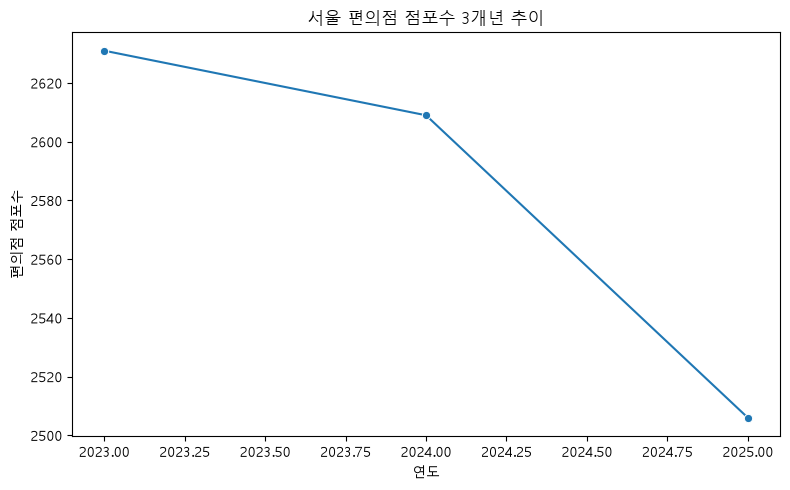

In [19]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=market,
    x="연도",
    y="점포_수",
    marker="o"
)

plt.title("서울 편의점 점포수 3개년 추이")
plt.xlabel("연도")
plt.ylabel("편의점 점포수")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "01_서울_편의점_추이.png",
    dpi=150
)

plt.show()

### STEP 6. 2025년 지역별 편의점 규모

#### 편의점이 많은 곳은 어디인가?

In [20]:

latest = store[
    store["연도"] == 2025
].copy()

region_2025 = (
    latest
    .groupby(
        ["행정동_코드", "지역명"]
    )["점포_수"]
    .sum()
    .reset_index()
    .sort_values(
        "점포_수",
        ascending=False
    )
)

print("[STEP 6] 2025년 편의점 TOP 20")
print(region_2025.head(20))

[STEP 6] 2025년 편의점 TOP 20
       행정동_코드              지역명  점포_수
368  11680640         강남구 역삼1동    43
214  11440660          마포구 서교동    41
288  11560540         영등포구 여의동    39
19   11140550            중구 명동    30
8    11110615  종로구 종로1.2.3.4가동    26
276  11545510          금천구 가산동    26
398  11710642         송파구 문정2동    24
367  11680630         강남구 대치4동    22
65   11215710          광진구 화양동    22
342  11650530         서초구 서초3동    21
18   11140540           중구 회현동    20
251  11500603         강서구 가양1동    18
359  11680521         강남구 논현1동    17
363  11680580         강남구 삼성1동    16
80   11230536         동대문구 용신동    16
237  11470650         양천구 신정4동    16
366  11680610         강남구 대치2동    15
401  11710650         송파구 잠실본동    15
195  11410585         서대문구 신촌동    15
364  11680590         강남구 삼성2동    15


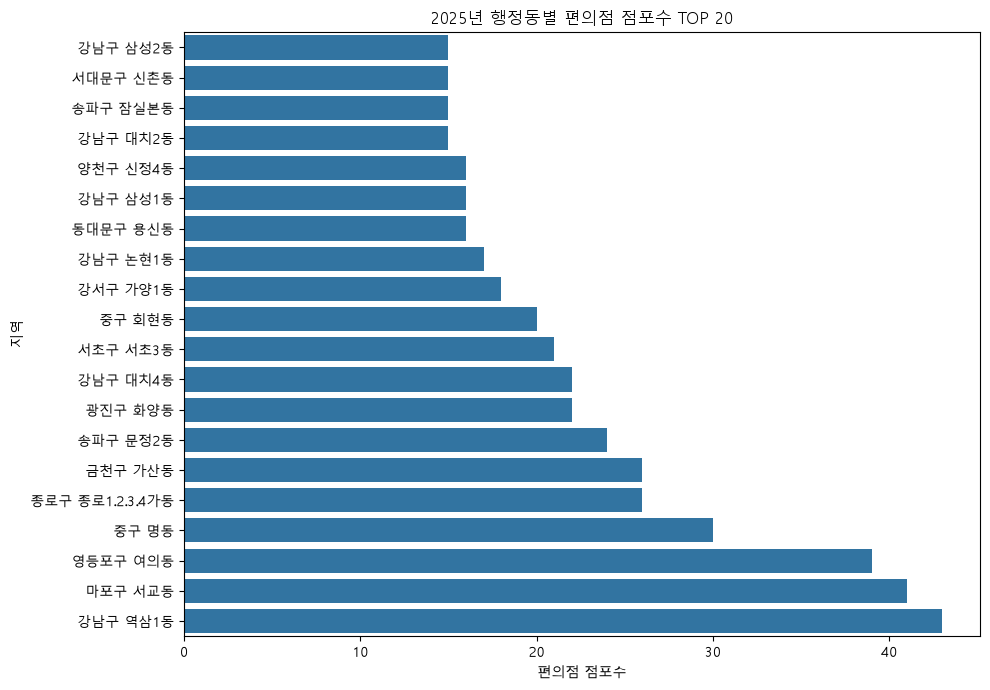

In [21]:
top20 = (
    region_2025
    .head(20)
    .sort_values("점포_수")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top20,
    x="점포_수",
    y="지역명"
)

plt.title("2025년 행정동별 편의점 점포수 TOP 20")
plt.xlabel("편의점 점포수")
plt.ylabel("지역")

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "02_행정동_편의점_TOP20.png",
    dpi=150
)

plt.show()

### STEP 7. 3개년 지역별 변화

In [22]:

region_pivot = (
    store
    .pivot_table(
        index=[
            "행정동_코드",
            "지역명"
        ],
        columns="연도",
        values="점포_수",
        aggfunc="sum"
    )
    .reset_index()
)

region_pivot.columns.name = None

region_pivot["3년_증감"] = (
    region_pivot[2025]
    - region_pivot[2023]
)

increase_top = (
    region_pivot
    .sort_values(
        "3년_증감",
        ascending=False
    )
    .head(10)
)

decrease_top = (
    region_pivot
    .sort_values(
        "3년_증감"
    )
    .head(10)
)

print("[STEP 7] 증가 TOP 10")
print(
    increase_top[
        [
            "지역명",
            2023,
            2025,
            "3년_증감"
        ]
    ]
)

print("\n[STEP 7] 감소 TOP 10")
print(
    decrease_top[
        [
            "지역명",
            2023,
            2025,
            "3년_증감"
        ]
    ]
)

[STEP 7] 증가 TOP 10
                 지역명  2023  2025  3년_증감
8    종로구 종로1.2.3.4가동    21    26      5
214          마포구 서교동    36    41      5
56       성동구 금호2.3가동     4     9      5
79          광진구 구의3동     8    13      5
292         영등포구 문래동     7    11      4
213          마포구 서강동     8    12      4
398         송파구 문정2동    20    24      4
219         마포구 성산1동     6     9      3
282         금천구 시흥2동     0     3      3
147          도봉구 창5동     8    11      3

[STEP 7] 감소 TOP 10
          지역명  2023  2025  3년_증감
195  서대문구 신촌동    30    15    -15
368  강남구 역삼1동    51    43     -8
359  강남구 논현1동    23    17     -6
413  강동구 암사1동    10     4     -6
355  서초구 양재1동    15    10     -5
356  서초구 양재2동    15    10     -5
40   용산구 한강로동    19    14     -5
401  송파구 잠실본동    20    15     -5
360  강남구 논현2동    18    13     -5
68   광진구 중곡2동    10     5     -5


### STEP 8. 상주·직장·유동인구 결합

In [24]:

resident["행정동_코드"] = (
    resident["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)

worker["행정동_코드"] = (
    worker["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)

floating["행정동_코드"] = (
    floating["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)


print("resident:", resident["행정동_코드"].dtype)
print("worker:", worker["행정동_코드"].dtype)
print("floating:", floating["행정동_코드"].dtype)
print("dong_area:", dong_area["행정동_코드"].dtype)

resident: str
worker: str
floating: str
dong_area: str


In [25]:
print("population:", population["행정동_코드"].dtype)
print("dong_area:", dong_area["행정동_코드"].dtype)

population: int64
dong_area: str


In [26]:

# 2025년 4분기 데이터 추출
resident_2025 = resident[
    resident["기준_년분기_코드"] == 20254
].copy()

worker_2025 = worker[
    worker["기준_년분기_코드"] == 20254
].copy()

floating_2025 = floating[
    floating["기준_년분기_코드"] == 20254
].copy()


# ------------------------------------------------------------
# 행정동 코드 자료형 통일
# ------------------------------------------------------------

resident_2025["행정동_코드"] = (
    resident_2025["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)

worker_2025["행정동_코드"] = (
    worker_2025["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)

floating_2025["행정동_코드"] = (
    floating_2025["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)


# ------------------------------------------------------------
# 필요한 컬럼만 선택
# ------------------------------------------------------------

resident_2025 = resident_2025[
    [
        "행정동_코드",
        "총_상주인구_수"
    ]
]

worker_2025 = worker_2025[
    [
        "행정동_코드",
        "총_직장_인구_수"
    ]
]

floating_2025 = floating_2025[
    [
        "행정동_코드",
        "총_유동인구_수"
    ]
]


# ------------------------------------------------------------
# 상주인구 + 직장인구
# ------------------------------------------------------------

population = resident_2025.merge(
    worker_2025,
    on="행정동_코드",
    how="outer"
)


# ------------------------------------------------------------
# 유동인구 추가
# ------------------------------------------------------------

population = population.merge(
    floating_2025,
    on="행정동_코드",
    how="outer"
)


# ------------------------------------------------------------
# 혹시 merge 과정에서 자료형이 바뀌었을 경우
# 다시 한 번 행정동 코드 통일
# ------------------------------------------------------------

population["행정동_코드"] = (
    population["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)


# ------------------------------------------------------------
# 지역명 연결
# ------------------------------------------------------------

population = population.merge(
    dong_area[
        [
            "행정동_코드",
            "지역명"
        ]
    ],
    on="행정동_코드",
    how="left"
)


print("[STEP 8] 인구 데이터 결합 완료")

print(population.head())

print("\n행정동 코드 자료형:")
print(population["행정동_코드"].dtype)

print("\n인구 데이터 행정동 수:")
print(population["행정동_코드"].nunique())

[STEP 8] 인구 데이터 결합 완료
     행정동_코드  총_상주인구_수  총_직장_인구_수  총_유동인구_수        지역명
0  11110515     11328     5324.0   3348036  종로구 청운효자동
1  11110530      8992    45215.0   3910218    종로구 사직동
2  11110540      2247     4210.0    974927    종로구 삼청동
3  11110550      9034     1509.0    844176    종로구 부암동
4  11110560     17366    14903.0    911272    종로구 평창동

행정동 코드 자료형:
str

인구 데이터 행정동 수:
425


### STEP 9. 세대원수 데이터 전처리 + 행정동 코드 연결

In [27]:

household_gu_names = set(
    gu_area["자치구_명"]
)

household_records = []

current_gu = None


for _, row in household_raw.iterrows():

    dong_name = row["동별_정리"]

    # 자치구가 나오면 현재 자치구 변경
    if dong_name in household_gu_names:

        current_gu = dong_name
        continue

    # 분석에 필요없는 행 제외
    if dong_name in [
        "합계",
        "서울시",
        "nan",
        ""
    ]:

        continue

    # 자치구 정보 추가
    record = row.to_dict()

    record["자치구_명"] = current_gu

    household_records.append(record)


household = pd.DataFrame(
    household_records
)

print("세대 데이터 정리 완료")
print(household.head())

세대 데이터 정리 완료
      동별    항목 단위 2025. 1/4 2025. 2/4 2025. 3/4 2025. 4/4 2025 년  Unnamed: 8  \
0  청운효자동  전체세대         4915      4914      4914      4873   4873         NaN   
1  청운효자동  1인세대         1901      1905      1884      1857   1857         NaN   
2  청운효자동  2인세대         1183      1186      1204      1215   1215         NaN   
3  청운효자동  3인세대          927       931       949       942    942         NaN   
4  청운효자동  4인세대          668       661       650       624    624         NaN   

   동별_정리 자치구_명  
0  청운효자동   종로구  
1  청운효자동   종로구  
2  청운효자동   종로구  
3  청운효자동   종로구  
4  청운효자동   종로구  


#### 행정동 연결

In [28]:
household = household.merge(
    dong_area[
        [
            "행정동_코드",
            "자치구_명",
            "행정동_명_정리",
            "지역명"
        ]
    ],
    left_on=[
        "자치구_명",
        "동별_정리"
    ],
    right_on=[
        "자치구_명",
        "행정동_명_정리"
    ],
    how="left"
)

print("\n세대 데이터 코드 매핑")
print(
    "전체 행:",
    len(household)
)

print(
    "행정동 코드 미매칭:",
    household["행정동_코드"].isna().sum()
)


세대 데이터 코드 매핑
전체 행: 4708
행정동 코드 미매칭: 55


#### 숫자변환

In [29]:
household["2025. 4/4"] = (
    household["2025. 4/4"]
    .replace("-", "0")
)

household["2025 년"] = (
    household["2025 년"]
    .replace("-", "0")
)

household["2025. 4/4"] = pd.to_numeric(
    household["2025. 4/4"],
    errors="coerce"
)

household["2025 년"] = pd.to_numeric(
    household["2025 년"],
    errors="coerce"
)

#### 행열 변경

In [33]:
household_wide = (
    household
    .pivot_table(
        index="행정동_코드",
        columns="항목",
        values="2025 년",
        aggfunc="first"
    )
    .reset_index()
)

household_wide.columns.name = None

#### 컬럼명 변경

In [34]:
household_wide = household_wide.rename(
    columns={
        "전체세대": "총_가구_수",
        "1인세대": "1인_가구_수",
        "2인세대": "2인_가구_수",
        "3인세대": "3인_가구_수",
        "4인세대": "4인_가구_수",
        "5인세대": "5인_가구_수",
        "6인세대": "6인_가구_수",
        "7인세대": "7인_가구_수",
        "8인세대": "8인_가구_수",
        "9인세대": "9인_가구_수",
        "10인세대 이상": "10인_이상_가구_수"
    }
)

#### population에 결합

In [35]:
population = population.merge(
    household_wide,
    on="행정동_코드",
    how="left"
)

print(population.head())

     행정동_코드  총_상주인구_수  총_직장_인구_수  총_유동인구_수        지역명  10인_이상_가구_수  1인_가구_수  \
0  11110515     11328     5324.0   3348036  종로구 청운효자동          1.0   1857.0   
1  11110530      8992    45215.0   3910218    종로구 사직동          4.0   2369.0   
2  11110540      2247     4210.0    974927    종로구 삼청동          0.0    526.0   
3  11110550      9034     1509.0    844176    종로구 부암동          1.0   1670.0   
4  11110560     17366    14903.0    911272    종로구 평창동          1.0   2224.0   

   2인_가구_수  3인_가구_수  4인_가구_수  5인_가구_수  6인_가구_수  7인_가구_수  8인_가구_수  9인_가구_수  \
0   1215.0    942.0    624.0    172.0     46.0     10.0      4.0      2.0   
1    946.0    667.0    456.0    110.0     18.0     11.0      3.0      0.0   
2    246.0    139.0    109.0     31.0     12.0      1.0      0.0      1.0   
3   1036.0    733.0    475.0    138.0     39.0     12.0      4.0      1.0   
4   1912.0   1438.0   1064.0    348.0     76.0     21.0     11.0      1.0   

   총_가구_수  
0  4873.0  
1  4584.0  
2  1065.0  
3  4109.0  
4 

### STEP 10. 상권특성 분류용 지표

편의점 포화도를 설명하기 위한 비율이 아니라 상권 특성을 구분하기 위한 내부 지표다.

In [36]:

population["1인_가구_비중"] = (
    population["1인_가구_수"]
    / population["총_가구_수"]
)

population["직장인구_상주인구_비"] = (
    population["총_직장_인구_수"]
    / population["총_상주인구_수"]
)

population["유동인구_상주인구_비"] = (
    population["총_유동인구_수"]
    / population["총_상주인구_수"]
)


print("[STEP 10]")
print(
    population[
        [
            "지역명",
            "1인_가구_비중",
            "직장인구_상주인구_비",
            "유동인구_상주인구_비"
        ]
    ].head()
)

[STEP 10]
         지역명  1인_가구_비중  직장인구_상주인구_비  유동인구_상주인구_비
0  종로구 청운효자동  0.381079     0.469986   295.554025
1    종로구 사직동  0.516798     5.028359   434.855205
2    종로구 삼청동  0.493897     1.873609   433.879395
3    종로구 부암동  0.406425     0.167036    93.444321
4    종로구 평창동  0.313416     0.858171    52.474490


### STEP 11. 학원·교육 상권 보조지표

학원 매출 데이터는 학원 상권을 직관적으로 분류하기 위한 보조자료로 사용

In [39]:

# 2025년 4분기 매출 데이터
sales_2025 = sales[
    sales["기준_년분기_코드"] == 20254
].copy()


# 매출 금액 숫자형 변환
sales_2025["당월_매출_금액"] = pd.to_numeric(
    sales_2025["당월_매출_금액"],
    errors="coerce"
).fillna(0)


# ------------------------------------------------------------
# 행정동 코드 자료형 통일
# ------------------------------------------------------------

sales_2025["행정동_코드"] = (
    sales_2025["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)


# ------------------------------------------------------------
# 전체 매출
# ------------------------------------------------------------

total_sales = (
    sales_2025
    .groupby("행정동_코드")["당월_매출_금액"]
    .sum()
    .reset_index()
)


total_sales = total_sales.rename(
    columns={
        "당월_매출_금액": "전체_매출"
    }
)


# ------------------------------------------------------------
# 학원 관련 매출
# ------------------------------------------------------------

academy_sales = (
    sales_2025[
        sales_2025["서비스_업종_코드_명"]
        .str.contains("학원", na=False)
    ]
    .groupby("행정동_코드")["당월_매출_금액"]
    .sum()
    .reset_index()
)


academy_sales = academy_sales.rename(
    columns={
        "당월_매출_금액": "학원_매출"
    }
)


# ------------------------------------------------------------
# 전체 매출 + 학원 매출
# ------------------------------------------------------------

academy = total_sales.merge(
    academy_sales,
    on="행정동_코드",
    how="left"
)


academy["학원_매출"] = (
    academy["학원_매출"]
    .fillna(0)
)


# ------------------------------------------------------------
# 학원 매출 비중
# ------------------------------------------------------------

academy["학원_매출_비중"] = (
    academy["학원_매출"]
    / academy["전체_매출"].replace(0, np.nan)
)


# ------------------------------------------------------------
# population과 연결하기 전 코드 자료형 확인
# ------------------------------------------------------------

academy["행정동_코드"] = (
    academy["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)


population["행정동_코드"] = (
    population["행정동_코드"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)


# ------------------------------------------------------------
# population에 학원 지표 연결
# ------------------------------------------------------------

population = population.merge(
    academy[
        [
            "행정동_코드",
            "학원_매출",
            "학원_매출_비중"
        ]
    ],
    on="행정동_코드",
    how="left"
)


print("[STEP 11] 학원 상권 보조지표 완료")

print(
    population[
        [
            "행정동_코드",
            "지역명",
            "학원_매출",
            "학원_매출_비중"
        ]
    ].head(10)
)

[STEP 11] 학원 상권 보조지표 완료
     행정동_코드              지역명         학원_매출  학원_매출_비중
0  11110515        종로구 청운효자동  1.376184e+08  0.005309
1  11110530          종로구 사직동  1.379401e+09  0.012390
2  11110540          종로구 삼청동  0.000000e+00  0.000000
3  11110550          종로구 부암동  6.697257e+08  0.085122
4  11110560          종로구 평창동  3.625044e+08  0.044968
5  11110570          종로구 무악동  2.693270e+07  0.003285
6  11110580          종로구 교남동  1.414809e+08  0.015541
7  11110600          종로구 가회동  1.290000e+08  0.004242
8  11110615  종로구 종로1.2.3.4가동  2.884002e+09  0.004880
9  11110630      종로구 종로5.6가동  0.000000e+00  0.000000


### STEP 12. 상권특성 분류

In [40]:

one_q75 = population[
    "1인_가구_비중"
].quantile(0.75)

office_q75 = population[
    "직장인구_상주인구_비"
].quantile(0.75)

floating_q75 = population[
    "유동인구_상주인구_비"
].quantile(0.75)

academy_q75 = population[
    "학원_매출_비중"
].quantile(0.75)


def classify_area(row):

    if (
        pd.notna(row["학원_매출_비중"])
        and row["학원_매출_비중"] >= academy_q75
    ):
        return "학원·교육형"

    elif (
        row["1인_가구_비중"] >= one_q75
    ):
        return "1인가구형"

    elif (
        row["직장인구_상주인구_비"] >= office_q75
    ):
        return "오피스형"

    elif (
        row["유동인구_상주인구_비"] >= floating_q75
    ):
        return "유동 중심형"

    else:
        return "주거형"


population["상권특성"] = (
    population.apply(
        classify_area,
        axis=1
    )
)


print("[STEP 12] 상권 특성별 지역 수")
print(
    population["상권특성"]
    .value_counts()
)

[STEP 12] 상권 특성별 지역 수
상권특성
주거형       136
학원·교육형    107
1인가구형     102
오피스형       52
유동 중심형     28
Name: count, dtype: int64


### STEP 13. 상권특성 × 편의점
"이런 특징을 가진 상권에는 편의점이 얼마나 있는가?"

In [41]:

analysis = region_pivot.merge(
    population,
    on=[
        "행정동_코드",
        "지역명"
    ],
    how="left"
)


commercial_summary = (
    analysis
    .groupby(
        "상권특성",
        as_index=False
    )
    .agg(
        지역수=(
            "행정동_코드",
            "nunique"
        ),

        편의점수_2025=(
            2025,
            "sum"
        ),

        편의점수_2023=(
            2023,
            "sum"
        ),

        평균_편의점수=(
            2025,
            "mean"
        )
    )
)


commercial_summary["3년_증감"] = (
    commercial_summary["편의점수_2025"]
    - commercial_summary["편의점수_2023"]
)


print("[STEP 13]")
print(
    commercial_summary
    .sort_values(
        "편의점수_2025",
        ascending=False
    )
)

[STEP 13]
     상권특성  지역수  편의점수_2025  편의점수_2023   평균_편의점수  3년_증감
0   1인가구형  102        860        919  8.431373    -59
3     주거형  136        620        637  4.558824    -17
4  학원·교육형  107        482        503  4.504673    -21
1    오피스형   52        402        414  7.730769    -12
2  유동 중심형   28        142        158  5.071429    -16


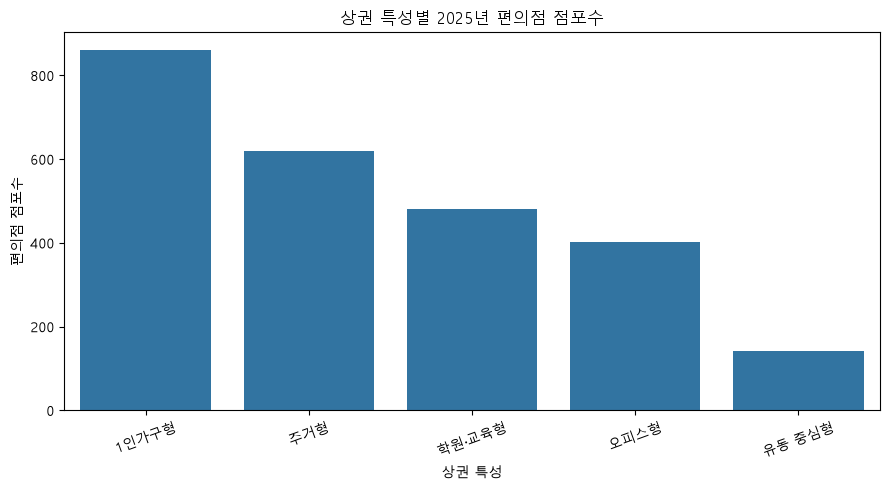

In [42]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=commercial_summary.sort_values(
        "편의점수_2025",
        ascending=False
    ),
    x="상권특성",
    y="편의점수_2025"
)

plt.title("상권 특성별 2025년 편의점 점포수")
plt.xlabel("상권 특성")
plt.ylabel("편의점 점포수")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_상권특성별_편의점수.png",
    dpi=150
)

plt.show()

여기서는 총점포수 + 평균점포수 + 3년 증감을 같이 본다.

### STEP 14. 경쟁/과밀도 1차 분류
"과밀"이라고 단정하지 않고 "경쟁수준"으로 표현한다.

In [43]:

store_q75 = (
    analysis[2025]
    .quantile(0.75)
)

store_q25 = (
    analysis[2025]
    .quantile(0.25)
)

change_q75 = (
    analysis["3년_증감"]
    .quantile(0.75)
)

change_q25 = (
    analysis["3년_증감"]
    .quantile(0.25)
)


def competition_level(row):

    count = row[2025]
    change = row["3년_증감"]

    if (
        count >= store_q75
        and change >= change_q75
    ):
        return "고밀·경쟁 지속"

    elif (
        count >= store_q75
        and change <= change_q25
    ):
        return "고밀·경쟁 완화"

    elif (
        count <= store_q25
        and change >= change_q75
    ):
        return "저밀·성장"

    elif (
        count <= store_q25
        and change <= change_q25
    ):
        return "저밀·상대적 여유"

    else:
        return "중간"


analysis["경쟁수준"] = (
    analysis.apply(
        competition_level,
        axis=1
    )
)


print("[STEP 14] 경쟁 수준")
print(
    analysis["경쟁수준"]
    .value_counts()
)

[STEP 14] 경쟁 수준
경쟁수준
중간           290
고밀·경쟁 완화      47
고밀·경쟁 지속      43
저밀·상대적 여유     40
저밀·성장          5
Name: count, dtype: int64


### STEP 15. 수요 대비 경쟁 보조 분석
활동인구 1,000명당 편의점 수를 만들며, 핵심 판단 기준이 아니라 보조 검증 지표라는 것.

점포수가 적다고 무조건 기회지역은 아니며, 최종 후보 검증용으로 사용

In [44]:

analysis["활동인구"] = (
    analysis["총_상주인구_수"].fillna(0)
    + analysis["총_직장_인구_수"].fillna(0)
)


analysis["활동인구_대비_편의점"] = (
    analysis[2025]
    / analysis["활동인구"].replace(
        0,
        np.nan
    )
    * 1000
)


print("[STEP 15]")
print(
    analysis[
        [
            "지역명",
            "활동인구",
            2025,
            "활동인구_대비_편의점"
        ]
    ].head(20)
)

[STEP 15]
                지역명      활동인구  2025  활동인구_대비_편의점
0         종로구 청운효자동   16652.0     3     0.180159
1           종로구 사직동   54207.0     4     0.073791
2           종로구 삼청동    6457.0     1     0.154871
3           종로구 부암동   10543.0     4     0.379399
4           종로구 평창동   32269.0     2     0.061979
5           종로구 무악동    8448.0     0     0.000000
6           종로구 교남동   10585.0     5     0.472367
7           종로구 가회동   16845.0     1     0.059365
8   종로구 종로1.2.3.4가동  116391.0    26     0.223385
9       종로구 종로5.6가동   24338.0     3     0.123264
10          종로구 이화동    8523.0     4     0.469318
11          종로구 혜화동   20210.0     7     0.346363
12         종로구 창신1동    6256.0     1     0.159847
13         종로구 창신2동    7539.0     0     0.000000
14         종로구 창신3동    6415.0     0     0.000000
15         종로구 숭인1동    5979.0     4     0.669008
16         종로구 숭인2동   10824.0     2     0.184775
17           중구 소공동   94436.0    10     0.105892
18           중구 회현동   74365.0    20     0.268944
19        

### STEP 16. 최종 창업 후보지역
상권 특징이 있고 + 수요가 있고 + 경쟁이 상대적으로 낮은 곳은 어디인가?

In [45]:

activity_q25 = (
    analysis["활동인구"]
    .quantile(0.25)
)


candidate = analysis[
    (
        analysis["활동인구"]
        >= activity_q25
    )
    &
    (
        (analysis[2025] <= store_q25)
        |
        (analysis["3년_증감"] <= change_q25)
    )
].copy()


# 후보 점수
candidate["후보점수"] = 0


# 점포수가 적으면 +1
candidate.loc[
    candidate[2025] <= store_q25,
    "후보점수"
] += 1


# 최근 3년간 점포수가 감소했으면 +1
candidate.loc[
    candidate["3년_증감"] <= change_q25,
    "후보점수"
] += 1


# 활동인구가 중앙값 이상이면 +1
activity_median = (
    analysis["활동인구"]
    .median()
)

candidate.loc[
    candidate["활동인구"] >= activity_median,
    "후보점수"
] += 1


candidate = candidate.sort_values(
    [
        "후보점수",
        "활동인구"
    ],
    ascending=[
        False,
        False
    ]
)


candidate_columns = [
    "지역명",
    "상권특성",
    "경쟁수준",
    2023,
    2025,
    "3년_증감",
    "총_상주인구_수",
    "총_직장_인구_수",
    "총_유동인구_수",
    "활동인구",
    "활동인구_대비_편의점",
    "후보점수"
]


print("[STEP 16] 창업 후보지역 TOP 30")

print(
    candidate[
        candidate_columns
    ].head(30)
)

[STEP 16] 창업 후보지역 TOP 30
            지역명    상권특성       경쟁수준  2023  2025  3년_증감  총_상주인구_수  총_직장_인구_수  \
226     양천구 목5동  학원·교육형  저밀·상대적 여유     2     1     -1     40702    15114.0   
168    노원구 상계1동     주거형  저밀·상대적 여유     3     2     -1     36834     3606.0   
4       종로구 평창동    오피스형  저밀·상대적 여유     3     2     -1     17366    14903.0   
26       중구 약수동    오피스형  저밀·상대적 여유     5     2     -3     16086    13696.0   
239    양천구 신정7동  학원·교육형  저밀·상대적 여유     2     1     -1     28275      349.0   
187    은평구 신사1동     주거형  저밀·상대적 여유     3     2     -1     26462     1400.0   
184    은평구 응암2동     주거형  저밀·상대적 여유     4     2     -2     27329      481.0   
149    도봉구 도봉2동     주거형  저밀·상대적 여유     2     1     -1     25990     1070.0   
317   동작구 신대방1동     주거형  저밀·상대적 여유     2     1     -1     23282     3411.0   
197   서대문구 홍제1동     주거형  저밀·상대적 여유     2     0     -2     24704     1814.0   
279    금천구 독산3동   1인가구형  저밀·상대적 여유     4     2     -2     23433     2738.0   
99   중랑구 면목3.8동     주거형  저밀·상대적 여유     

### STEP 17. PPT용 세부 시각화 + 결과표

#### 경쟁수준별 지역 수

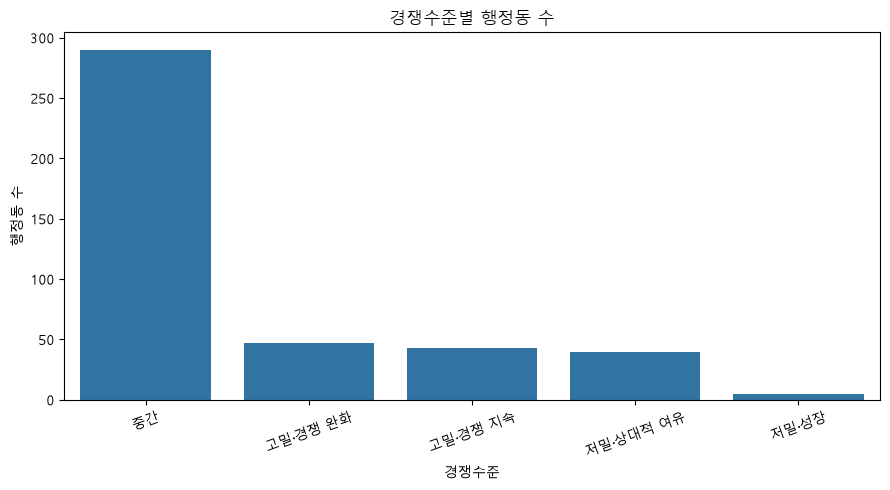

In [46]:

competition_summary = (
    analysis["경쟁수준"]
    .value_counts()
    .reset_index()
)

competition_summary.columns = [
    "경쟁수준",
    "지역수"
]


plt.figure(figsize=(9, 5))

sns.barplot(
    data=competition_summary,
    x="경쟁수준",
    y="지역수"
)

plt.title("경쟁수준별 행정동 수")
plt.xlabel("경쟁수준")
plt.ylabel("행정동 수")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "04_경쟁수준별_지역수.png",
    dpi=150
)

plt.show()

#### 17-2. 상권특성별 지역 수

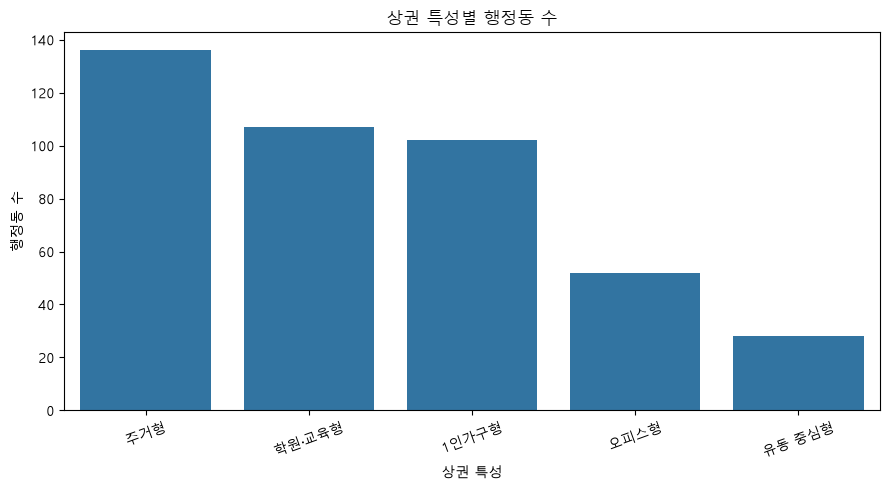

In [47]:

area_type_summary = (
    analysis["상권특성"]
    .value_counts()
    .reset_index()
)

area_type_summary.columns = [
    "상권특성",
    "지역수"
]


plt.figure(figsize=(9, 5))

sns.barplot(
    data=area_type_summary,
    x="상권특성",
    y="지역수"
)

plt.title("상권 특성별 행정동 수")
plt.xlabel("상권 특성")
plt.ylabel("행정동 수")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_상권특성별_지역수.png",
    dpi=150
)

plt.show()

#### 17-3. 후보지역 TOP 20

In [48]:

candidate_top20 = (
    candidate[
        candidate_columns
    ]
    .head(20)
    .copy()
)


print(candidate_top20)

            지역명    상권특성       경쟁수준  2023  2025  3년_증감  총_상주인구_수  총_직장_인구_수  \
226     양천구 목5동  학원·교육형  저밀·상대적 여유     2     1     -1     40702    15114.0   
168    노원구 상계1동     주거형  저밀·상대적 여유     3     2     -1     36834     3606.0   
4       종로구 평창동    오피스형  저밀·상대적 여유     3     2     -1     17366    14903.0   
26       중구 약수동    오피스형  저밀·상대적 여유     5     2     -3     16086    13696.0   
239    양천구 신정7동  학원·교육형  저밀·상대적 여유     2     1     -1     28275      349.0   
187    은평구 신사1동     주거형  저밀·상대적 여유     3     2     -1     26462     1400.0   
184    은평구 응암2동     주거형  저밀·상대적 여유     4     2     -2     27329      481.0   
149    도봉구 도봉2동     주거형  저밀·상대적 여유     2     1     -1     25990     1070.0   
317   동작구 신대방1동     주거형  저밀·상대적 여유     2     1     -1     23282     3411.0   
197   서대문구 홍제1동     주거형  저밀·상대적 여유     2     0     -2     24704     1814.0   
279    금천구 독산3동   1인가구형  저밀·상대적 여유     4     2     -2     23433     2738.0   
99   중랑구 면목3.8동     주거형  저밀·상대적 여유     5     2     -3     24375 

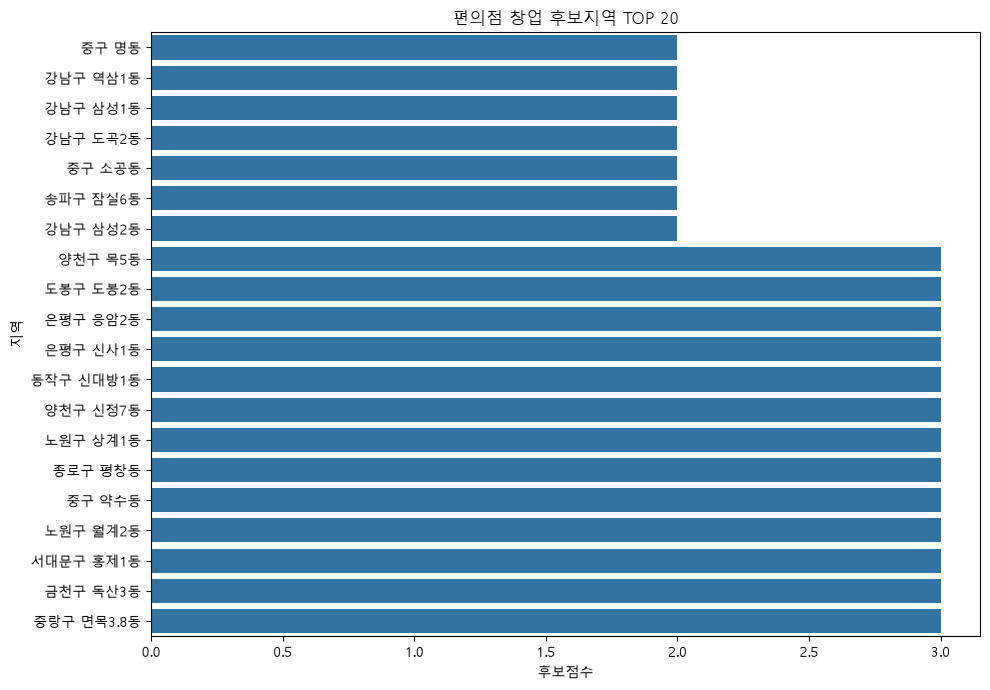

In [49]:
plt.figure(figsize=(10, 7))

candidate_graph = (
    candidate_top20
    .sort_values("후보점수")
)

sns.barplot(
    data=candidate_graph,
    x="후보점수",
    y="지역명"
)

plt.title("편의점 창업 후보지역 TOP 20")
plt.xlabel("후보점수")
plt.ylabel("지역")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_창업_후보지역_TOP20.png",
    dpi=150
)

plt.show()

### STEP 18. 최종 결과 저장 + 요약

In [50]:
# 1. 서울 전체 시장 추이
market.to_csv(
    OUTPUT_DIR / "market_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# 2. 지역별 3개년 변화
region_pivot.to_csv(
    OUTPUT_DIR / "region_store_change.csv",
    index=False,
    encoding="utf-8-sig"
)


# 3. 상권특성별 편의점 현황
commercial_summary.to_csv(
    OUTPUT_DIR / "commercial_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# 4. 최종 분석 데이터
analysis.to_csv(
    OUTPUT_DIR / "final_analysis_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)


# 5. 창업 후보지역
candidate[
    candidate_columns
].head(50).to_csv(
    OUTPUT_DIR / "startup_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)


# 6. 상권특성별 지역 수
area_type_summary.to_csv(
    OUTPUT_DIR / "area_type_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# 7. 경쟁수준별 지역 수
competition_summary.to_csv(
    OUTPUT_DIR / "competition_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


print("=" * 60)
print("분석 완료")
print("=" * 60)

print("\n[주요 결과]")
print("서울 2023 편의점:", market.loc[market["연도"] == 2023, "점포_수"].iloc[0])
print("서울 2025 편의점:", market.loc[market["연도"] == 2025, "점포_수"].iloc[0])

print(
    "\n창업 후보지역:",
    len(candidate)
)

print(
    "\n결과 파일 저장 위치:",
    OUTPUT_DIR.resolve()
)

분석 완료

[주요 결과]
서울 2023 편의점: 2631
서울 2025 편의점: 2506

창업 후보지역: 150

결과 파일 저장 위치: C:\Users\pomel\Downloads\cvs_analysis\output
